In [49]:
import matplotlib.pyplot as plt
import pickle

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

In [ ]:
nome_do_arquivo = 'triplet.pkl'

with open(nome_do_arquivo, 'rb') as arquivo:
    exp = pickle.load(arquivo)
    data = exp['data']
    model = exp['model']

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f23e57aa070>>
Traceback (most recent call last):
  File "/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
  File "_pydevd_bundle/pydevd_cython.pyx", line 1457, in _pydevd_bundle.pydevd_cython.SafeCallWrapper.__call__
  File "_pydevd_bundle/pydevd_cython.pyx", line 1758, in _pydevd_bundle.pydevd_cython.ThreadTracer.__call__
  File "/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_is_thread_alive.py", line 9, in is_thread_alive
    def is_thread_alive(t):
KeyboardInterrupt: 


In [ ]:
expansions = {
    'estimated_p': ['p0', 'p1'],
    's_': ['s0', 's1', 's2', 's3'],
    's__': ['s_0', 's_1', 's_2', 's_3'],
}


df = data.evaluation_data[data.evaluation_data['episode'] == 98].copy().reset_index(drop=True)
df = get_data_expanded(df, expansions)
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,p0,p1,s0,s1,s2,s3,s_0,s_1,s_2,s_3
0,0,98,"(0.1955406148449595, 0.6245501454716056)","(0.044, 0.035, -0.043, -0.021)",1,1.0,"(0.045, 0.229, -0.043, -0.284)",0.0,1.0,"(0.05, 0.036, -0.049, -0.044)",...,0.300,0.521,0.045,0.229,-0.043,-0.284,0.050,0.036,-0.049,-0.044
1,1,98,"(0.1955406148449595, 0.6245501454716056)","(0.045, 0.229, -0.043, -0.284)",0,1.0,"(0.05, 0.036, -0.049, -0.044)",0.0,1.0,"(0.05, -0.156, -0.05, 0.194)",...,0.234,0.633,0.050,0.036,-0.049,-0.044,0.050,-0.156,-0.050,0.194
2,2,98,"(0.1955406148449595, 0.6245501454716056)","(0.05, 0.036, -0.049, -0.044)",0,1.0,"(0.05, -0.156, -0.05, 0.194)",0.0,1.0,"(0.047, -0.349, -0.046, 0.432)",...,0.247,0.593,0.050,-0.156,-0.050,0.194,0.047,-0.349,-0.046,0.432
3,3,98,"(0.1955406148449595, 0.6245501454716056)","(0.05, -0.156, -0.05, 0.194)",0,1.0,"(0.047, -0.349, -0.046, 0.432)",1.0,1.0,"(0.04, -0.155, -0.037, 0.168)",...,0.277,0.620,0.047,-0.349,-0.046,0.432,0.040,-0.155,-0.037,0.168
4,4,98,"(0.1955406148449595, 0.6245501454716056)","(0.047, -0.349, -0.046, 0.432)",1,1.0,"(0.04, -0.155, -0.037, 0.168)",0.0,1.0,"(0.037, -0.348, -0.034, 0.41)",...,0.290,0.505,0.040,-0.155,-0.037,0.168,0.037,-0.348,-0.034,0.410


# Treino 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

target_value = torch.tensor(df[['s_0', 's_1', 's_2', 's_3']].values)
param = torch.tensor(df[['p0', 'p1']].mean().values, requires_grad=True)
print(f'initial value for input Param: {[round(p,4) for p in param.tolist()]}') 
input_values = torch.tensor(df[['s0', 's1', 's2', 's3', 'a_']].values) 
input_size = 4+1+2
hidden_size = 10
output_size = 2
learning_rate = 0.1
num_epochs = 1000

m = model.transition_estimator.state_layer
optimizer = optim.Adam([param], lr=learning_rate)
criterion = nn.MSELoss(reduction='none')

# 4. Optimization Loop
history = []

for p in m.parameters():
    p.requires_grad = False


for epoch in range(num_epochs):
    # Forward pass
    state_inputs = torch.concat([input_values, param.repeat((input_values.shape[0], 1))], dim=1)
    output = m(state_inputs.float())  # Add batch dimension

    # Calculate the loss
    mins = input_values[:,:-1].min(axis=0).values.repeat((output.shape[0], 1))
    rang = input_values[:,:-1].max(axis=0).values.repeat((output.shape[0], 1)) - mins
    normalized_outputs = (output - mins) / rang
    loss = criterion(normalized_outputs.float(), target_value.float())
    loss = loss.sum(axis=1).mean()

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history.append((epoch, param.tolist(), loss.item()))

    if (epoch + 1) % 100 == 0:
        # print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Input Param: {param.item():.4f}, Output: {output.item():.4f}')
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Input Param: {[round(p,4) for p in param.tolist()]}')


initial value for input Param: [0.2661, 0.6582]
Epoch [100/1000], Loss: 1.5788, Input Param: [3.5583, -6.0529]
Epoch [200/1000], Loss: 1.5787, Input Param: [3.5103, -5.9393]
Epoch [300/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [400/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [500/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [600/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [700/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [800/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [900/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]
Epoch [1000/1000], Loss: 1.5787, Input Param: [3.5103, -5.9394]


In [ ]:
results = data.get_evaluation_metrics()
df_result = results[results['episode'] == 98].copy()

In [ ]:
df_result['rmse'] = df_result['rse_s0'] + df_result['rse_s1'] + df_result['rse_s2'] + df_result['rse_s3']
df_result.rmse.mean()

np.float64(0.051638554216867465)

# Original Predictions:

In [ ]:
import numpy as np

df = get_data_expanded(data.evaluation_data[data.evaluation_data.episode==98], {
    's_':['s0','s1','s2','s3'], 's__':['s_0','s_1','s_2','s_3'], 'p':['p_0','p_1'],
    'estimated_s':['estimated_s0','estimated_s1','estimated_s2','estimated_s3'], #'estimated_p':['estimated_p_0','estimated_p_1']
})
np.sqrt(np.pow(df.estimated_s0 - df.s_0, 2) + np.pow(df.estimated_s1 - df.s_1, 2) + np.pow(df.estimated_s3 - df.s_3, 2) + np.pow(df.estimated_s2 - df.s_2, 2)).sum()

np.float64(2.830452240462948)

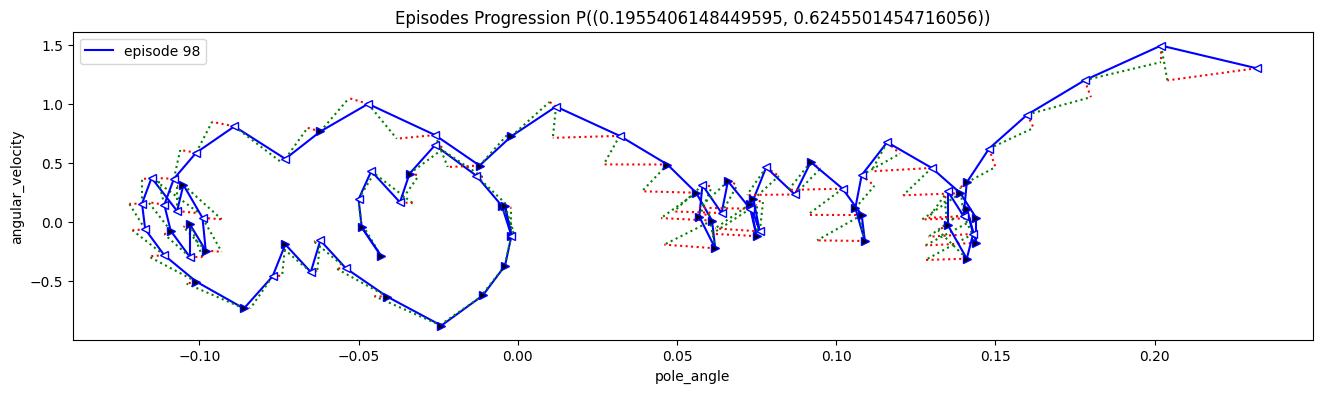

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(16, 4))
data.plot_episode_progression_with_predictions(axs, 98)
plt.show()

# Optimized Param:

In [ ]:
import numpy as np

df = get_data_expanded(data.evaluation_data[data.evaluation_data.episode==98], {
    's_':['s0','s1','s2','s3'], 's__':['s_0','s_1','s_2','s_3'], 'p':['p_0','p_1'],
    # 'estimated_s':['estimated_s0','estimated_s1','estimated_s2','estimated_s3'], #'estimated_p':['estimated_p_0','estimated_p_1']
})
df[['estimated_s0','estimated_s1','estimated_s2','estimated_s3']] = output.detach().numpy() 


np.sqrt(np.pow(df.estimated_s0 - df.s_0, 2) + np.pow(df.estimated_s1 - df.s_1, 2) + np.pow(df.estimated_s3 - df.s_3, 2) + np.pow(df.estimated_s2 - df.s_2, 2)).sum()

np.float64(47.55233611966228)

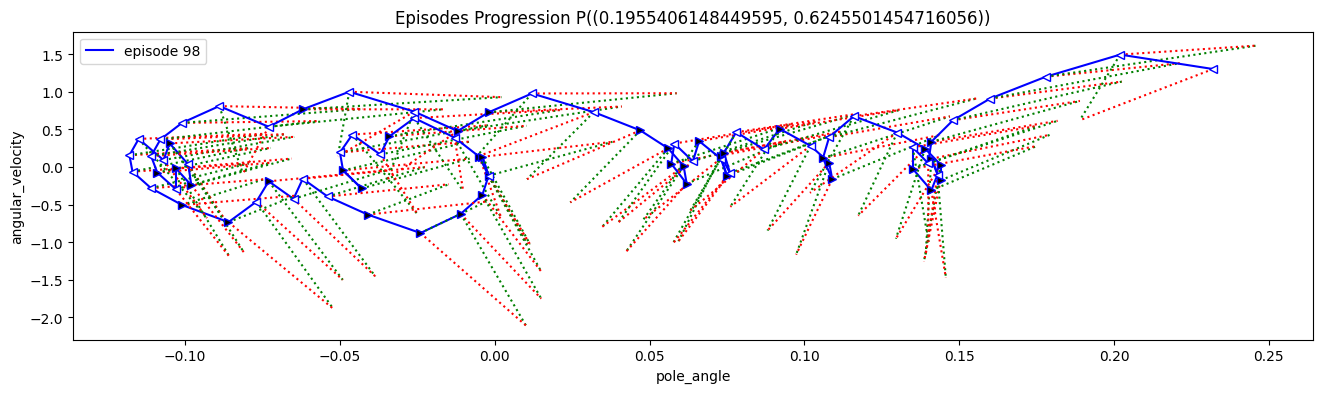

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))
data.plot_episode_progression_with_predictions(axs, 98, df=df)
plt.show()